In [49]:
import torch
torch_version = str(torch.__version__)
scatter_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
sparse_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
!pip install torch-scatter -f $scatter_src
!pip install torch-sparse -f $sparse_src
!pip install torch-geometric
!pip install pyg-lib
!pip install scikit-learn

Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html


ERROR: Could not find a version that satisfies the requirement pyg-lib (from versions: none)
ERROR: No matching distribution found for pyg-lib


In [50]:
import torch
print(torch.__version__)
import torch_geometric
print(torch_geometric.__version__)

2.2.2+cpu
2.6.1


In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
from torch_geometric.nn import MessagePassing
from sklearn.model_selection import train_test_split
from torch_geometric.data import HeteroData

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_sparse import SparseTensor

class TemporalEncoding(nn.Module):
    """Sinusoidal temporal encoding for time-aware graph processing"""
    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        # Fix: Ensure even hidden_size for sinusoidal encoding
        if hidden_size % 2 != 0:
            hidden_size = hidden_size + 1
        self.register_buffer('inv_freq', 1.0 / (10000 ** (torch.arange(0.0, hidden_size, 2.0) / hidden_size)))

    def forward(self, pos):
        # Fix: Handle device properly and dimension issues
        sinusoid_inp = pos.float().unsqueeze(-1) * self.inv_freq
        # Fix: Ensure output has correct hidden_size
        pos_emb = torch.cat([torch.sin(sinusoid_inp), torch.cos(sinusoid_inp)], dim=-1)
        return pos_emb[:, :self.hidden_size]  # Truncate to exact hidden_size

class CrossDatasetMetaLearner(nn.Module):

    def __init__(
        self,
        hidden_size,
        num_relations,
        num_datasets=1
    ):
        super().__init__()

        self.hidden_size = hidden_size

        self.meta_relation = nn.Embedding(
            num_relations,
            hidden_size
        )

        self.dataset_emb = nn.Embedding(
            num_datasets,
            hidden_size
        )

        self.meta_mlp = nn.Sequential(
            nn.Linear(
                hidden_size,
                hidden_size
            ),
            nn.ReLU(),
            nn.Linear(
                hidden_size,
                hidden_size * hidden_size
                + hidden_size
            )
        )

    def forward(
        self,
        relation_types,
        dataset_id
    ):

        rel_id = relation_types[0]

        rel_emb = self.meta_relation(
            rel_id
        )

        data_emb = self.dataset_emb(
            dataset_id
        )

        meta_input = (
            rel_emb + data_emb
        )

        params = self.meta_mlp(
            meta_input
        )

        weight_size = (
            self.hidden_size
            *
            self.hidden_size
        )

        weight = params[
            :weight_size
        ].view(
            self.hidden_size,
            self.hidden_size
        )

        bias = params[
            weight_size:
        ]

        return {
            'weight': weight,
            'bias': bias
        }
    
    
class HierarchicalAttention(nn.Module):
    """Two-level attention: edge-level and node-level attention"""
    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        # Edge-level attention components
        self.edge_attn_linear = nn.Linear(hidden_size * 3, 1)  # src, dst, relation
        self.edge_attn_activation = nn.LeakyReLU(0.2)

        # Node-level attention components
        self.node_attn_linear = nn.Linear(hidden_size * 2, 1)  # aggregated_msg, self
        self.node_attn_activation = nn.LeakyReLU(0.2)

    def edge_level_attention(self, src_features, dst_features, relation_emb, time_emb):
        """Compute attention weights for each edge"""
        combined = torch.cat([src_features, dst_features, relation_emb + time_emb], dim=-1)
        edge_scores = self.edge_attn_linear(combined)
        edge_scores = self.edge_attn_activation(edge_scores)
        return torch.sigmoid(edge_scores)

    def node_level_attention(self, self_features, aggregated_messages):
        """Compute attention for combining different relation types"""
        combined = torch.cat([self_features, aggregated_messages], dim=-1)
        node_scores = self.node_attn_linear(combined)
        node_scores = self.node_attn_activation(node_scores)
        return torch.sigmoid(node_scores)

class DynamicMetaAttentionConv_Attn(nn.Module):
    """DMAHGT Convolution Layer with Dataset-Aware Meta Learning"""

    def __init__(
        self,
        in_channels,
        out_channels,
        hidden_size,
        num_relations
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_relations = num_relations

        # Relation Embeddings
        self.relation_emb = nn.Embedding(
            num_relations,
            hidden_size
        )

        # Temporal Encoding
        self.temporal_encoding = TemporalEncoding(
            hidden_size
        )

        # Cross-Dataset Meta Learner
        self.meta_learner = CrossDatasetMetaLearner(
            hidden_size,
            num_relations,
            num_datasets=1
        )

        # Hierarchical Attention
        self.hierarchical_attention = (
            HierarchicalAttention(
                hidden_size
            )
        )

        # Feature Transformations
        self.src_transform = nn.Linear(
            in_channels,
            hidden_size
        )

        self.dst_transform = nn.Linear(
            in_channels,
            hidden_size
        )

        self.output_transform = nn.Linear(
            hidden_size,
            out_channels
        )

        self.layer_norm = nn.LayerNorm(
            hidden_size
        )

    def forward(
        self,
        src_x,
        dst_x,
        edge_index,
        edge_type,
        edge_time,
        dataset_id
    ):

        # =====================================
        # Relation Embeddings
        # =====================================
        rel_emb = self.relation_emb(
            edge_type
        )

        # =====================================
        # Temporal Encoding
        # =====================================
        if edge_time is not None:

            time_emb = self.temporal_encoding(
                edge_time.float()
            )

        else:

            time_emb = torch.zeros(
                rel_emb.size(0),
                self.hidden_size,
                device=src_x.device
            )

        # =====================================
        # Dataset-Aware Meta Learning
        # =====================================
        meta_params = self.meta_learner(
            edge_type,
            dataset_id
        )

        # =====================================
        # Node Feature Transformations
        # =====================================
        src_transformed = (
            self.src_transform(src_x)
        )

        dst_transformed = (
            self.dst_transform(dst_x)
        )

        # =====================================
        # Tensor / SparseTensor Support
        # =====================================
        if isinstance(
            edge_index,
            SparseTensor
        ):

            row, col, _ = edge_index.coo()

            src_nodes = src_transformed[
                row
            ]

            dst_nodes = dst_transformed[
                col
            ]

            target_indices = col

        else:

            src_nodes = src_transformed[
                edge_index[0]
            ]

            dst_nodes = dst_transformed[
                edge_index[1]
            ]

            target_indices = edge_index[1]

        # =====================================
        # Edge-Level Attention
        # =====================================
        edge_weights = (
            self.hierarchical_attention
            .edge_level_attention(
                src_nodes,
                dst_nodes,
                rel_emb,
                time_emb
            )
        )

        # =====================================
        # Dynamic Relation Parameters
        # =====================================
        weight = meta_params['weight']
        bias = meta_params['bias']

        transformed_src = (
            src_nodes @ weight
        ) + bias

        # =====================================
        # Attention-Weighted Messages
        # =====================================
        weighted_messages = (
            transformed_src
            * edge_weights
        )

        # =====================================
        # Message Aggregation
        # =====================================
        aggregated = torch.zeros_like(
            dst_transformed
        )

        aggregated.index_add_(
            0,
            target_indices,
            weighted_messages
        )

        # =====================================
        # Node-Level Attention
        # =====================================
        node_weights = (
            self.hierarchical_attention
            .node_level_attention(
                dst_transformed,
                aggregated
            )
        )

        # =====================================
        # Residual Aggregation
        # =====================================
        output = (
            dst_transformed
            +
            aggregated
            * node_weights
        )

        # =====================================
        # LayerNorm
        # =====================================
        output = self.layer_norm(
            output
        )

        # =====================================
        # Output Projection
        # =====================================
        output = self.output_transform(
            output
        )

        return output


class DMA_HGT(nn.Module):

    def __init__(self, hetero_graph, args):
        super().__init__()

        self.hidden_size = args['hidden_size']
        self.num_layers = args['num_layers']
        self.dropout = args['dropout']
        self.device = args['device']

        # Dataset ID (MovieLens = 0)
        self.dataset_id = torch.tensor(
            0,
            dtype=torch.long,
            device=self.device
        )

        # ==========================
        # Node Embeddings
        # ==========================
        self.node_emb = nn.ModuleDict()

        for node_type in hetero_graph.node_types:
            self.node_emb[node_type] = nn.Linear(
                hetero_graph[node_type].x.shape[1],
                self.hidden_size
            ).to(self.device)

        # ==========================
        # Relation Types
        # ==========================
        self.relation_types = sorted(
            list(
                set(
                    [
                        edge_type[1]
                        for edge_type in hetero_graph.edge_types
                    ]
                )
            )
        )

        self.relation_dict = {
            rel: idx
            for idx, rel in enumerate(
                self.relation_types
            )
        }

        # ==========================
        # DMAHGT Layers
        # ==========================
        self.convs = nn.ModuleList()

        for _ in range(self.num_layers):

            self.convs.append(
                DynamicMetaAttentionConv_Attn(
                    self.hidden_size,
                    self.hidden_size,
                    self.hidden_size,
                    num_relations=len(
                        self.relation_types
                    )
                ).to(self.device)
            )

        # ==========================
        # LayerNorm
        # ==========================
        self.temporal_norm = nn.LayerNorm(
            self.hidden_size
        ).to(self.device)

        # ==========================
        # Explainability
        # ==========================
        self.importance_proj = nn.Linear(
            self.hidden_size,
            1
        ).to(self.device)

    # ==========================================
    # Link Prediction Decoder
    # ==========================================
    def decode(
        self,
        user_emb,
        artist_emb,
        edge_index
    ):

        src = user_emb[
        edge_index[0]
        ]

        dst = artist_emb[
            edge_index[1]
        ]

        return (
          src * dst
        ).sum(dim=1)

    # ==========================================
    # Forward
    # ==========================================
    def forward(
        self,
        node_features,
        edge_indices,
        edge_timestamps=None
    ):

        x = {}

        for node_type, feat in node_features.items():

            x[node_type] = (
                self.node_emb[node_type](
                    feat.to(self.device)
                )
            )

        for conv in self.convs:

            x_new = {}

            for (
                message_type,
                edge_index
            ) in edge_indices.items():

                src_type, rel_type, dst_type = (
                    message_type
                )

                if isinstance(
                    edge_index,
                    SparseTensor
                ):

                    nnz = edge_index.nnz()
                    edge_index_tensor = edge_index

                else:

                    nnz = edge_index.size(1)
                    edge_index_tensor = edge_index

                rel_idx = torch.full(
                    (nnz,),
                    self.relation_dict[
                        rel_type
                    ],
                    dtype=torch.long,
                    device=self.device
                )

                if (
                    edge_timestamps is not None
                    and message_type in edge_timestamps
                ):

                    edge_time = (
                        edge_timestamps[
                            message_type
                        ].to(
                            self.device
                        )
                    )

                else:

                    edge_time = torch.zeros(
                        nnz,
                        dtype=torch.float,
                        device=self.device
                    )

                out = conv(
                    src_x=x[src_type],
                    dst_x=x[dst_type],
                    edge_index=edge_index_tensor,
                    edge_type=rel_idx,
                    edge_time=edge_time,
                    dataset_id=self.dataset_id
                )

                if dst_type not in x_new:

                    x_new[dst_type] = out

                else:

                    x_new[dst_type] += out

            for node_type in x:

                if node_type in x_new:

                    x[node_type] = (
                        self.temporal_norm(
                            x[node_type]
                            +
                            x_new[node_type]
                        )
                    )

                x[node_type] = F.dropout(
                    x[node_type],
                    p=self.dropout,
                    training=self.training
                )

        importance = {}

        for node_type in x:

            importance[node_type] = (
                self.importance_proj(
                    x[node_type]
                )
            )

        return x, importance

In [53]:
import torch.optim as optim
def setup_optimizer_and_scheduler(configuration, model_params):
    weight_decay = configuration.weight_decay
    trainable_params = filter(lambda p: p.requires_grad, model_params)

    if configuration.optimizer == 'adam':
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)
    elif configuration.optimizer == 'sgd':
        optimizer = torch.optim.SGD(trainable_params, lr=configuration.learning_rate, momentum=0.95, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)
        
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=max(1, configuration.epochs),eta_min=1e-6)

    return scheduler, optimizer      

## Training and Testing

In [54]:
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
import numpy as np
from torch_geometric.data import HeteroData
import requests
import zipfile
import io
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import trange
import torch
import torch.nn.functional as F
from torch_geometric.utils import negative_sampling
from sklearn.model_selection import train_test_split
import numpy as np

def download_and_extract_lastfm():
    """Download LastFM HetRec 2011 dataset and extract it"""

    print("Downloading LastFM dataset...")

    url = "https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip"

    response = requests.get(url, timeout=60)

    if response.status_code != 200:
        raise Exception(
            f"Failed to download dataset: HTTP {response.status_code}"
        )

    extract_path = "lastfm"

    if not os.path.exists(extract_path):
        os.makedirs(extract_path)

    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset downloaded and extracted successfully!")

    extracted_folder = os.path.join(
        extract_path,
        "hetrec2011-lastfm-2k"
    )

    if os.path.exists(extracted_folder):
        print(f"Files extracted to: {extracted_folder}")
        return extracted_folder

    print("Contents of extraction directory:")

    for root, dirs, files in os.walk(extract_path):
        level = root.replace(extract_path, "").count(os.sep)

        indent = " " * 2 * level

        print(f"{indent}{os.path.basename(root)}/")

        subindent = " " * 2 * (level + 1)

        for file in files:
            print(f"{subindent}{file}")

    return extract_path

def encode_user_features(
        user_artists_df,
        user_friends_df,
        user_taggedartists_df,
        user_id_to_idx
):
    """
    Create user features for LastFM
    """

    num_users = len(user_id_to_idx)

    friend_count = np.zeros(num_users)
    artist_count = np.zeros(num_users)
    tag_count = np.zeros(num_users)
    listening_count = np.zeros(num_users)

    # --------------------------
    # Friend count
    # --------------------------
    for _, row in user_friends_df.iterrows():

        uid = row['userID']

        if uid in user_id_to_idx:

            friend_count[
                user_id_to_idx[uid]
            ] += 1

    # --------------------------
    # Artist count
    # --------------------------
    artist_groups = user_artists_df.groupby(
        'userID'
    )

    for uid, group in artist_groups:

        if uid in user_id_to_idx:

            idx = user_id_to_idx[uid]

            artist_count[idx] = len(group)

            listening_count[idx] = (
                group['weight'].sum()
            )

    # --------------------------
    # Tag count
    # --------------------------
    tag_groups = (
        user_taggedartists_df
        .groupby('userID')
    )

    for uid, group in tag_groups:

        if uid in user_id_to_idx:

            idx = user_id_to_idx[uid]

            tag_count[idx] = (
                group['tagID']
                .nunique()
            )

    # --------------------------
    # Normalize
    # --------------------------
    features = np.stack(
        [
            friend_count,
            artist_count,
            tag_count,
            listening_count
        ],
        axis=1
    )

    features = (
        features - features.min(axis=0)
    ) / (
        features.max(axis=0)
        - features.min(axis=0)
        + 1e-8
    )

    user_features = torch.tensor(
        features,
        dtype=torch.float
    )

    print(
        f"User feature dimension: "
        f"{user_features.shape[1]}"
    )

    return user_features

def encode_artist_features(
        artists_df,
        user_artists_df,
        user_taggedartists_df,
        artist_id_to_idx
):
    """
    Create artist features for LastFM
    """

    num_artists = len(artist_id_to_idx)

    listener_count = np.zeros(num_artists)
    total_weight = np.zeros(num_artists)
    avg_weight = np.zeros(num_artists)
    unique_tag_count = np.zeros(num_artists)
    tag_assignment_count = np.zeros(num_artists)

    # --------------------------
    # Listening statistics
    # --------------------------
    artist_groups = (
        user_artists_df.groupby(
            'artistID'
        )
    )

    for artist_id, group in artist_groups:

        if artist_id in artist_id_to_idx:

            idx = artist_id_to_idx[
                artist_id
            ]

            listener_count[idx] = (
                group['userID']
                .nunique()
            )

            total_weight[idx] = np.log1p(
                group['weight'].sum()
            )

            avg_weight[idx] = np.log1p(
                group['weight'].mean()
            )

    # --------------------------
    # Tag statistics
    # --------------------------
    tag_groups = (
        user_taggedartists_df.groupby(
            'artistID'
        )
    )

    for artist_id, group in tag_groups:

        if artist_id in artist_id_to_idx:

            idx = artist_id_to_idx[
                artist_id
            ]

            unique_tag_count[idx] = (
                group['tagID']
                .nunique()
            )

            tag_assignment_count[idx] = (
                len(group)
            )

    # --------------------------
    # Feature matrix
    # --------------------------
    features = np.stack(
        [
            listener_count,
            total_weight,
            avg_weight,
            unique_tag_count,
            tag_assignment_count
        ],
        axis=1
    )

    # Min-Max normalization
    features = (
        features - features.min(axis=0)
    ) / (
        features.max(axis=0)
        - features.min(axis=0)
        + 1e-8
    )

    artist_features = torch.tensor(
        features,
        dtype=torch.float
    )

    print(
        f"Artist feature dimension: "
        f"{artist_features.shape[1]}"
    )

    return artist_features

def encode_tag_features(
        tags_df,
        user_taggedartists_df,
        tag_id_to_idx
):
    """
    Create tag features for LastFM
    """

    num_tags = len(tag_id_to_idx)

    usage_count = np.zeros(num_tags)
    unique_user_count = np.zeros(num_tags)
    unique_artist_count = np.zeros(num_tags)

    # =====================================
    # Tag Statistics
    # =====================================

    tag_groups = user_taggedartists_df.groupby(
        'tagID'
    )

    for tag_id, group in tag_groups:

        if tag_id in tag_id_to_idx:

            idx = tag_id_to_idx[tag_id]

            # Total tag assignments
            usage_count[idx] = len(group)

            # Number of unique users
            unique_user_count[idx] = (
                group['userID']
                .nunique()
            )

            # Number of unique artists
            unique_artist_count[idx] = (
                group['artistID']
                .nunique()
            )

    # =====================================
    # Feature Matrix
    # =====================================

    features = np.stack(
        [
            usage_count,
            unique_user_count,
            unique_artist_count
        ],
        axis=1
    )

    # =====================================
    # Min-Max Normalization
    # =====================================

    features = (
        features - features.min(axis=0)
    ) / (
        features.max(axis=0)
        - features.min(axis=0)
        + 1e-8
    )

    tag_features = torch.tensor(
        features,
        dtype=torch.float
    )

    print(
        f"Tag feature dimension: "
        f"{tag_features.shape[1]}"
    )

    return tag_features




def load_lastfm_heterogeneous(
    data_path,
    use_features=True,
    use_temporal=True
):
    """Load LastFM dataset with real features and timestamps"""

    print(
        f"Loading LastFM dataset from: "
        f"{data_path}"
    )

    print("\nAvailable files in directory:")

    try:
        for f in os.listdir(data_path):
            print(f"  - {f}")
    except:
        print(
            "  Could not list directory contents"
        )

    # ==========================================
    # Load artists
    # ==========================================

    try:

        artists_df = pd.read_csv(
            os.path.join(
                data_path,
                'artists.dat'
            ),
            sep='\t',
            encoding='latin-1'
        )

        print(
            f"✓ Loaded artists.dat: "
            f"{len(artists_df)} records"
        )

    except Exception as e:

        print(
            f"✗ artists.dat not found "
            f"or error: {e}"
        )

        raise

    # ==========================================
    # Load user-artists
    # ==========================================

    try:

        user_artists_df = pd.read_csv(
            os.path.join(
                data_path,
                'user_artists.dat'
            ),
            sep='\t'
        )

        print(
            f"✓ Loaded user_artists.dat: "
            f"{len(user_artists_df)} records"
        )

    except Exception as e:

        print(
            f"✗ user_artists.dat not found "
            f"or error: {e}"
        )

        raise

    # ==========================================
    # Load user-friends
    # ==========================================

    try:

        user_friends_df = pd.read_csv(
            os.path.join(
                data_path,
                'user_friends.dat'
            ),
            sep='\t'
        )

        print(
            f"✓ Loaded user_friends.dat: "
            f"{len(user_friends_df)} records"
        )

    except Exception as e:

        print(
            f"✗ user_friends.dat not found "
            f"or error: {e}"
        )

        raise

    # ==========================================
    # Load tags
    # ==========================================

    try:

        tags_df = pd.read_csv(
            os.path.join(
                data_path,
                'tags.dat'
            ),
            sep='\t',
            encoding='latin-1'
        )

        print(
            f"✓ Loaded tags.dat: "
            f"{len(tags_df)} records"
        )

    except Exception as e:

        print(
            f"✗ tags.dat not found "
            f"or error: {e}"
        )

        raise

    # ==========================================
    # Load tagged artists
    # ==========================================

    try:

        timestamp_file = os.path.join(
            data_path,
            'user_taggedartists-timestamps.dat'
        )

        regular_file = os.path.join(
            data_path,
            'user_taggedartists.dat'
        )

        if os.path.exists(
            timestamp_file
        ):

            user_taggedartists_df = pd.read_csv(
                timestamp_file,
                sep='\t'
            )

            print(
                f"✓ Loaded "
                f"user_taggedartists-timestamps.dat: "
                f"{len(user_taggedartists_df)} records"
            )

        else:

            user_taggedartists_df = pd.read_csv(
                regular_file,
                sep='\t'
            )

            print(
                f"✓ Loaded "
                f"user_taggedartists.dat: "
                f"{len(user_taggedartists_df)} records"
            )

    except Exception as e:

        print(
            f"✗ user_taggedartists file "
            f"not found or error: {e}"
        )

        raise

    # =====================================================
    # Create HeteroData
    # =====================================================

    data = HeteroData()

    # =====================================================
    # Unique Users
    # =====================================================

    all_users = (
        set(user_artists_df['userID'])
        .union(set(user_friends_df['userID']))
        .union(set(user_friends_df['friendID']))
        .union(set(user_taggedartists_df['userID']))
    )

    # =====================================================
    # Unique Artists
    # =====================================================

    all_artists = (
        set(artists_df['id'])
        .union(set(user_artists_df['artistID']))
        .union(set(user_taggedartists_df['artistID']))
    )

    # =====================================================
    # Unique Tags
    # =====================================================

    all_tags = (
        set(tags_df['tagID'])
        .union(set(user_taggedartists_df['tagID']))
    )

    num_users = len(all_users)
    num_artists = len(all_artists)
    num_tags = len(all_tags)

    user_id_to_idx = {
        uid: i
        for i, uid in enumerate(sorted(all_users))
    }

    artist_id_to_idx = {
        aid: i
        for i, aid in enumerate(sorted(all_artists))
    }

    tag_id_to_idx = {
        tid: i
        for i, tid in enumerate(sorted(all_tags))
    }

    print(
        f"\nStatistics - "
        f"Users: {num_users}, "
        f"Artists: {num_artists}, "
        f"Tags: {num_tags}"
    )

    # =====================================================
    # Encode Features
    # =====================================================

    user_feat_dim = 0
    artist_feat_dim = 0
    tag_feat_dim = 0

    if use_features:

        user_features = encode_user_features(
            user_artists_df,
            user_friends_df,
            user_taggedartists_df,
            user_id_to_idx
        )

        artist_features = encode_artist_features(
            artists_df,
            user_artists_df,
            user_taggedartists_df,
            artist_id_to_idx
        )

        tag_features = encode_tag_features(
            tags_df,
            user_taggedartists_df,
            tag_id_to_idx
        )

        user_feat_dim = user_features.shape[1]
        artist_feat_dim = artist_features.shape[1]
        tag_feat_dim = tag_features.shape[1]

        print("\nFeature dimensions:")
        print(f"  User features   : {user_feat_dim}")
        print(f"  Artist features : {artist_feat_dim}")
        print(f"  Tag features    : {tag_feat_dim}")

        data['user'].x = user_features
        data['artist'].x = artist_features
        data['tag'].x = tag_features

    # =====================================================
    # Store Node Counts
    # =====================================================

    data['user'].num_nodes = num_users
    data['artist'].num_nodes = num_artists
    data['tag'].num_nodes = num_tags

    # =====================================================
    # USER → ARTIST (LISTENS)
    # =====================================================
    listens_edge_index = []
    listens_edge_weight = []
    valid_listens = 0

    for _, row in user_artists_df.iterrows():
        uid = row['userID']
        aid = row['artistID']

        if uid in user_id_to_idx and aid in artist_id_to_idx:
            listens_edge_index.append([
                user_id_to_idx[uid],
                artist_id_to_idx[aid]
            ])
            listens_edge_weight.append(
                np.log1p(float(row['weight']))
            )
            valid_listens += 1

    listens_edge_index = torch.tensor(
        listens_edge_index, 
        dtype=torch.long
    ).t().contiguous()

    listens_edge_weight = torch.tensor(
        listens_edge_weight, 
        dtype=torch.float
    )

    data['user', 'listens', 'artist'].edge_index = listens_edge_index
    data['user', 'listens', 'artist'].weight = (listens_edge_weight)
    data['artist', 'rev_listens', 'user'].edge_index = listens_edge_index.flip(0)
    data['artist', 'rev_listens', 'user'].weight = (listens_edge_weight)
    data['user', 'listens', 'artist'].original_edge_index = listens_edge_index.clone()
    
    
   
    print(f"User→Artist relations: {valid_listens}")

    # =====================================================
    # USER → USER (FRIENDS)
    # =====================================================
    friend_edges = []

    for _, row in user_friends_df.iterrows():
        u1 = row['userID']
        u2 = row['friendID']

        if u1 in user_id_to_idx and u2 in user_id_to_idx:
            friend_edges.append([
                user_id_to_idx[u1],
                user_id_to_idx[u2]
            ])

    friend_edges = torch.tensor(
        friend_edges, 
        dtype=torch.long
    ).t().contiguous()
    
    
    reverse_friend_edges = friend_edges.flip(0)

    friend_edges = torch.cat(
        [
            friend_edges,
            reverse_friend_edges
        ],
        dim=1
    )

    data['user', 'friends', 'user'].edge_index = friend_edges

    
    print(f"User↔User relations: {friend_edges.size(1)}")

    # =====================================================
    # USER → ARTIST (TAGS)
    # =====================================================
    tag_edges = []
    timestamps = []

    for _, row in user_taggedartists_df.iterrows():
        uid = row['userID']
        aid = row['artistID']

        if uid in user_id_to_idx and aid in artist_id_to_idx:
            tag_edges.append([
                user_id_to_idx[uid],
                artist_id_to_idx[aid]
            ])

            if use_temporal and 'timestamp' in user_taggedartists_df.columns:
                timestamps.append(float(row['timestamp']))

    tag_edges = torch.tensor(
        tag_edges, 
        dtype=torch.long
    ).t().contiguous()

    data['user', 'tags', 'artist'].edge_index = tag_edges
    
    data[
        'artist',
        'rev_tags',
        'user'
    ].edge_index = tag_edges.flip(0)

    if use_temporal and len(timestamps) > 0:
        timestamps_tensor = torch.tensor(timestamps, dtype=torch.float)
        timestamps_tensor = (timestamps_tensor - timestamps_tensor.min()) / (
            timestamps_tensor.max() - timestamps_tensor.min() + 1e-8
        )
        data['user', 'tags', 'artist'].timestamp = timestamps_tensor

    print(f"User→Artist(tagged) relations: {tag_edges.size(1)}")

    # =====================================================
    # ARTIST → TAG
    # =====================================================
    artist_tag_edges = []
    seen_pairs = set()

    for _, row in user_taggedartists_df.iterrows():
        aid = row['artistID']
        tid = row['tagID']

        if aid in artist_id_to_idx and tid in tag_id_to_idx:
            pair = (artist_id_to_idx[aid], tag_id_to_idx[tid])
            
            if pair not in seen_pairs:
                seen_pairs.add(pair)
                artist_tag_edges.append(list(pair))

    artist_tag_edges = torch.tensor(
        artist_tag_edges, 
        dtype=torch.long
    ).t().contiguous()

    data['artist', 'tagged_with', 'tag'].edge_index = artist_tag_edges
    data['tag', 'rev_tagged_with', 'artist'].edge_index = artist_tag_edges.flip(0)

    print(f"Artist→Tag relations: {artist_tag_edges.size(1)}")

    # =====================================================
    # FINAL STATISTICS
    # =====================================================
    print("\nFINAL STATISTICS:")
    print(f"Users   : {num_users}")
    print(f"Artists : {num_artists}")
    print(f"Tags    : {num_tags}")
    print(f"User feature dimension   : {user_feat_dim}")
    print(f"Artist feature dimension : {artist_feat_dim}")
    print(f"Tag feature dimension    : {tag_feat_dim}")
    print(f"User→Artist edges : {valid_listens}")
    print(f"User→User edges   : {friend_edges.size(1)}")
    print(f"User→Artist tags  : {tag_edges.size(1)}")
    print(f"Artist→Tag edges  : {artist_tag_edges.size(1)}")

    return data


import torch
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import trange


def train_link_prediction_model(data, model, configuration):
    optimizer = optim.Adam(
        model.parameters(),
        lr=configuration.learning_rate,
        weight_decay=configuration.weight_decay,
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=configuration.epochs, eta_min=1e-6
    )

    losses = []
    val_aucs = []

    best_val_auc = 0.0
    best_model_state = None

    num_epochs = configuration.epochs

    for epoch in trange(num_epochs, desc="DMAHGT Training"):

        model.train()
        optimizer.zero_grad()

        node_features = {
            node_type: data[node_type].x for node_type in data.node_types
        }

        edge_indices = {
            edge_type: data[edge_type].edge_index for edge_type in data.edge_types
        }

        edge_timestamps = {}
        for edge_type in data.edge_types:
            if "timestamp" in data[edge_type]:
                edge_timestamps[edge_type] = data[edge_type].timestamp

        z, importance = model(node_features, edge_indices, edge_timestamps)

        user_emb = z["user"]
        artist_emb = z["artist"]

        pos_edge_index = data.train_pos_edge_index
        num_pos = pos_edge_index.size(1)

        neg_edge_index = negative_sampling(
            edge_index=pos_edge_index,
            num_nodes=(data["user"].num_nodes, data["artist"].num_nodes),
            num_neg_samples=num_pos,
        )

        pos_pred = model.decode(user_emb, artist_emb, pos_edge_index)
        neg_pred = model.decode(user_emb, artist_emb, neg_edge_index)

        pos_loss = -torch.log(torch.sigmoid(pos_pred) + 1e-15).mean()
        neg_loss = -torch.log(1 - torch.sigmoid(neg_pred) + 1e-15).mean()
        loss = pos_loss + neg_loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        losses.append(loss.item())

        if epoch % 5 == 0:
            model.eval()
            with torch.no_grad():
                z, importance = model(node_features, edge_indices, edge_timestamps)

                user_emb = z["user"]
                artist_emb = z["artist"]

                val_pred = model.decode(user_emb, artist_emb, data.val_edge_index)
                val_pred = torch.sigmoid(val_pred)

                val_auc = roc_auc_score(
                    data.val_edge_label.cpu().numpy(), val_pred.cpu().numpy()
                )
                val_aucs.append(val_auc)

                if val_auc > best_val_auc:
                    best_val_auc = val_auc
                    best_model_state = {
                        k: v.cpu().clone() for k, v in model.state_dict().items()
                    }

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        node_features = {
            node_type: data[node_type].x for node_type in data.node_types
        }

        edge_indices = {
            edge_type: data[edge_type].edge_index for edge_type in data.edge_types
        }

        edge_timestamps = {}
        for edge_type in data.edge_types:
            if "timestamp" in data[edge_type]:
                edge_timestamps[edge_type] = data[edge_type].timestamp

        z, importance = model(node_features, edge_indices, edge_timestamps)

        user_emb = z["user"]
        artist_emb = z["artist"]

        test_pred = model.decode(user_emb, artist_emb, data.test_edge_index)
        test_pred = torch.sigmoid(test_pred)

        test_auc = roc_auc_score(
            data.test_edge_label.cpu().numpy(), test_pred.cpu().numpy()
        )
        test_ap = average_precision_score(
            data.test_edge_label.cpu().numpy(), test_pred.cpu().numpy()
        )

    test_metrics = {"auc": test_auc, "ap": test_ap}

    return val_aucs, losses, model, test_metrics


def evaluate_recommendation_clean(model, data, k_list=[5, 10, 20]):
    """
    Fast LastFM recommendation evaluation
    Computes: HR@K, NDCG@K, MRR
    """
    model.eval()

    HR = {k: [] for k in k_list}
    NDCG = {k: [] for k in k_list}
    MRR = []

    with torch.no_grad():
        # =====================================
        # Generate embeddings
        # =====================================
        node_features = {
            node_type: data[node_type].x 
            for node_type in data.node_types
        }

        edge_indices = {
            edge_type: data[edge_type].edge_index 
            for edge_type in data.edge_types
        }

        edge_timestamps = {}
        for edge_type in data.edge_types:
            if 'timestamp' in data[edge_type]:
                edge_timestamps[edge_type] = data[edge_type].timestamp

        z, _ = model(node_features, edge_indices, edge_timestamps)

        user_emb = z['user']
        artist_emb = z['artist']

        # =====================================
        # Positive Test Edges
        # =====================================
        pos_edges = data.test_edge_index[:, data.test_edge_label == 1]

        if pos_edges.size(1) == 0:
            print("Warning: No positive test edges.")
            results = {}
            for k in k_list:
                results[f'HR@{k}'] = 0
                results[f'NDCG@{k}'] = 0
            results['MRR'] = 0
            return results

        # =====================================
        # Evaluate only subset
        # =====================================
        max_eval_edges = 5000
        if pos_edges.size(1) > max_eval_edges:
            eval_idx = np.random.choice(
                pos_edges.size(1), 
                max_eval_edges, 
                replace=False
            )
            pos_edges = pos_edges[:, eval_idx]

        # =====================================
        # Build User History
        # =====================================
        user_positive_artists = {}
               
        edge_sets = [(data.train_edge_index,data.train_edge_label),(data.val_edge_index,data.val_edge_label)]

        for edge_index, edge_label in edge_sets:
            positive_edges = edge_index[:, edge_label == 1]
            for i in range(positive_edges.size(1)):
                u = positive_edges[0, i].item()
                a = positive_edges[1, i].item()

                if u not in user_positive_artists:
                    user_positive_artists[u] = set()
                user_positive_artists[u].add(a)

        # =====================================
        # Artist Set
        # =====================================
        all_artists = set(range(data['artist'].num_nodes))

        # =====================================
        # Evaluate
        # =====================================
        for edge in pos_edges.t():
            user = edge[0].item()
            pos_artist = edge[1].item()

            user_seen = user_positive_artists.get(user, set())
            candidate_artists = list(all_artists- user_seen - {pos_artist})

            if len(candidate_artists) < 99:
                continue

            neg_artists = np.random.choice(candidate_artists, 99, replace=False)
            candidates = list(neg_artists) + [pos_artist]

            users = torch.full(
                (len(candidates),), 
                user, 
                dtype=torch.long, 
                device=user_emb.device
            )
            artists = torch.tensor(
                candidates, 
                dtype=torch.long, 
                device=user_emb.device
            )
            edge_index = torch.stack([users, artists])

            scores = model.decode(user_emb, artist_emb, edge_index)
            scores = scores.detach().cpu().numpy()

            ranking = np.argsort(scores)[::-1]
            ranked_artists = [candidates[i] for i in ranking]

            for k in k_list:
                if pos_artist in ranked_artists[:k]:
                    HR[k].append(1)
                    rank = ranked_artists.index(pos_artist) + 1
                    NDCG[k].append(1 / np.log2(rank + 1))
                else:
                    HR[k].append(0)
                    NDCG[k].append(0)

            rank = ranked_artists.index(pos_artist) + 1
            MRR.append(1.0 / rank)

    # =====================================
    # Final Metrics
    # =====================================
    results = {}
    for k in k_list:
        results[f'HR@{k}'] = np.mean(HR[k]) if len(HR[k]) > 0 else 0
        results[f'NDCG@{k}'] = np.mean(NDCG[k]) if len(NDCG[k]) > 0 else 0

    results['MRR'] = np.mean(MRR) if len(MRR) > 0 else 0

    return results

class Config:
    def __init__(self, parameters):
        self.__dict__.update(parameters)

In [55]:
from torch_geometric.utils import negative_sampling
import torch

def prepare_link_prediction_data(
    data,
    val_ratio=0.1,
    test_ratio=0.1
):
    """
    Prepare LastFM User-Artist Link Prediction Data
    """

    # =====================================
    # User → Artist Interaction Edges
    # =====================================

    edge_index = data[
        'user',
        'listens',
        'artist'
    ].edge_index

    num_edges = edge_index.size(1)

    perm = torch.randperm(num_edges)

    num_val = int(
        num_edges * val_ratio
    )

    num_test = int(
        num_edges * test_ratio
    )

    num_train = (
        num_edges
        - num_val
        - num_test
    )

    train_idx = perm[:num_train]

    val_idx = perm[
        num_train:
        num_train + num_val
    ]

    test_idx = perm[
        num_train + num_val:
    ]

    # =====================================
    # Positive Edges
    # =====================================

    train_pos_edge_index = (
        edge_index[:, train_idx]
    )

    val_pos_edge_index = (
        edge_index[:, val_idx]
    )

    test_pos_edge_index = (
        edge_index[:, test_idx]
    )

    # =====================================
    # Negative Sampling
    # =====================================

    train_neg_edge_index = (
        negative_sampling(
            edge_index=train_pos_edge_index,
            num_nodes=(
                data['user'].num_nodes,
                data['artist'].num_nodes
            ),
            num_neg_samples=
            train_pos_edge_index.size(1)
        )
    )

    val_neg_edge_index = (
        negative_sampling(
            edge_index=train_pos_edge_index,
            num_nodes=(
                data['user'].num_nodes,
                data['artist'].num_nodes
            ),
            num_neg_samples=
            val_pos_edge_index.size(1)
        )
    )

    test_neg_edge_index = (
        negative_sampling(
            edge_index=train_pos_edge_index,
            num_nodes=(
                data['user'].num_nodes,
                data['artist'].num_nodes
            ),
            num_neg_samples=
            test_pos_edge_index.size(1)
        )
    )

    # =====================================
    # Training Data
    # =====================================

    data.train_pos_edge_index = (
        train_pos_edge_index
    )

    data.train_edge_index = torch.cat(
        [
            train_pos_edge_index,
            train_neg_edge_index
        ],
        dim=1
    )

    data.train_edge_label = torch.cat(
        [
            torch.ones(
                train_pos_edge_index.size(1),
                dtype=torch.float
            ),
            torch.zeros(
                train_neg_edge_index.size(1),
                dtype=torch.float
            )
        ]
    )

    # Shuffle Training Edges

    train_perm = torch.randperm(
        data.train_edge_index.size(1)
    )

    data.train_edge_index = (
        data.train_edge_index[
            :,
            train_perm
        ]
    )

    data.train_edge_label = (
        data.train_edge_label[
            train_perm
        ]
    )

    # =====================================
    # Validation Data
    # =====================================

    data.val_edge_index = torch.cat(
        [
            val_pos_edge_index,
            val_neg_edge_index
        ],
        dim=1
    )

    data.val_edge_label = torch.cat(
        [
            torch.ones(
                val_pos_edge_index.size(1),
                dtype=torch.float
            ),
            torch.zeros(
                val_neg_edge_index.size(1),
                dtype=torch.float
            )
        ]
    )

    # =====================================
    # Test Data
    # =====================================

    data.test_edge_index = torch.cat(
        [
            test_pos_edge_index,
            test_neg_edge_index
        ],
        dim=1
    )

    data.test_edge_label = torch.cat(
        [
            torch.ones(
                test_pos_edge_index.size(1),
                dtype=torch.float
            ),
            torch.zeros(
                test_neg_edge_index.size(1),
                dtype=torch.float
            )
        ]
    )

    # =====================================
    # Statistics
    # =====================================

    print("\nLink Prediction Split")
    print("=" * 60)

    print(
        f"Train Positive Edges      : "
        f"{train_pos_edge_index.size(1)}"
    )

    print(
        f"Validation Positive Edges : "
        f"{val_pos_edge_index.size(1)}"
    )

    print(
        f"Test Positive Edges       : "
        f"{test_pos_edge_index.size(1)}"
    )

    print(
        f"Train Negative Edges      : "
        f"{train_neg_edge_index.size(1)}"
    )

    print(
        f"Validation Negative Edges : "
        f"{val_neg_edge_index.size(1)}"
    )

    print(
        f"Test Negative Edges       : "
        f"{test_neg_edge_index.size(1)}"
    )

    return data

Using device: cpu

STEP 1: Loading LastFM Dataset
Dataset downloaded and extracted successfully!
Contents of extraction directory:
lastfm/
  artists.dat
  readme.txt
  tags.dat
  user_artists.dat
  user_friends.dat
  user_taggedartists-timestamps.dat
  user_taggedartists.dat
Loading LastFM dataset from: lastfm

Available files in directory:
  - artists.dat
  - readme.txt
  - tags.dat
  - user_artists.dat
  - user_friends.dat
  - user_taggedartists-timestamps.dat
  - user_taggedartists.dat
✓ Loaded artists.dat: 17632 records
✓ Loaded user_artists.dat: 92834 records
✓ Loaded user_friends.dat: 25434 records
✓ Loaded tags.dat: 11946 records
✓ Loaded user_taggedartists-timestamps.dat: 186479 records

Statistics - Users: 1892, Artists: 18022, Tags: 11946
User feature dimension: 4
Artist feature dimension: 5
Tag feature dimension: 3

Feature dimensions:
  User features   : 4
  Artist features : 5
  Tag features    : 3
User→Artist relations: 92834
User↔User relations: 50868
User→Artist(tagged)

DMAHGT Training: 100%|███████████████████████████████████████████████████████████████| 200/200 [05:13<00:00,  1.57s/it]



FINAL RESULTS
Model: DMAHGT
Dataset: LastFM

--- LINK PREDICTION METRICS ---
AUC : 0.8867
AP  : 0.8875

--- RECOMMENDATION METRICS ---
HR@5   : 0.5698
HR@10  : 0.6952
HR@20  : 0.8040
NDCG@5  : 0.4296
NDCG@10 : 0.4703
NDCG@20 : 0.4980
MRR : 0.4125

Time Taken: 313.90 seconds


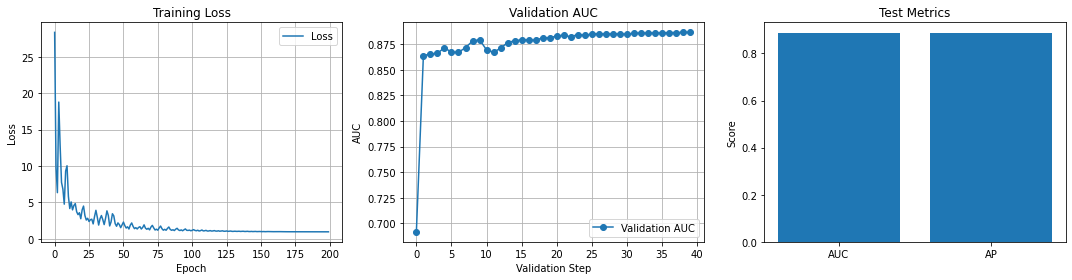

In [56]:
import torch
import time
import matplotlib.pyplot as plt

def main_link_prediction():
    configurations = [
        {
            'model_type': 'DMAHGT',
            'dataset': 'LastFM',
            'num_layers': 2,
            'heads': 1,
            'hidden_dim': 64,
            'embedding_dim': 64,
            'dropout': 0.3,
            'epochs': 200,
            'optimizer': 'adam',
            'weight_decay': 1e-5,
            'learning_rate': 0.001,
            'num_relation_types': 7,
            'use_temporal': True,
            'use_features': True
        }
    ]

    for config_dict in configurations:
        config = Config(config_dict)
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        print(f"Using device: {device}")
        print("\n" + "=" * 60)
        print("STEP 1: Loading LastFM Dataset")
        print("=" * 60)

        data_path = download_and_extract_lastfm()
        heterogeneous_data = load_lastfm_heterogeneous(
            data_path,
            use_features=config.use_features,
            use_temporal=config.use_temporal
        )
        heterogeneous_data = heterogeneous_data.to(device)

        print("\n" + "=" * 60)
        print("STEP 2: Preparing Data for Link Prediction")
        print("=" * 60)

        heterogeneous_data = prepare_link_prediction_data(heterogeneous_data)

        model_args = {
            'device': device,
            'hidden_size': config.hidden_dim,
            'num_layers': config.num_layers,
            'dropout': config.dropout
        }

        model = DMA_HGT(heterogeneous_data, model_args).to(device)

        print("\n" + "=" * 60)
        print("STEP 3: Training DMAHGT")
        print("=" * 60)

        start_time = time.time()
        val_aucs, losses, best_model, test_metrics = train_link_prediction_model(heterogeneous_data,model,config)
        elapsed_time = time.time() - start_time

        print("\n" + "=" * 60)
        print("FINAL RESULTS")
        print("=" * 60)
        print(f"Model: {config.model_type}")
        print(f"Dataset: {config.dataset}")

        print("\n--- LINK PREDICTION METRICS ---")
        print(f"AUC : {test_metrics['auc']:.4f}")
        print(f"AP  : {test_metrics['ap']:.4f}")

        print("\n--- RECOMMENDATION METRICS ---")
        rec_metrics = evaluate_recommendation_clean(best_model, heterogeneous_data)
        print(f"HR@5   : {rec_metrics['HR@5']:.4f}")
        print(f"HR@10  : {rec_metrics['HR@10']:.4f}")
        print(f"HR@20  : {rec_metrics['HR@20']:.4f}")
        print(f"NDCG@5  : {rec_metrics['NDCG@5']:.4f}")
        print(f"NDCG@10 : {rec_metrics['NDCG@10']:.4f}")
        print(f"NDCG@20 : {rec_metrics['NDCG@20']:.4f}")
        print(f"MRR : {rec_metrics['MRR']:.4f}")
        print(f"\nTime Taken: {elapsed_time:.2f} seconds")
        print("=" * 60)

        # =====================================
        # Plots
        # =====================================
        plt.figure(figsize=(15, 4))

        # Training Loss
        plt.subplot(1, 3, 1)
        plt.plot(losses, label="Loss")
        plt.title("Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)

        # Validation AUC
        plt.subplot(1, 3, 2)
        plt.plot(val_aucs, marker='o', label='Validation AUC')
        plt.title("Validation AUC")
        plt.xlabel("Validation Step")
        plt.ylabel("AUC")
        plt.legend()
        plt.grid(True)

        # Test Metrics
        plt.subplot(1, 3, 3)
        plt.bar(['AUC', 'AP'], [test_metrics['auc'], test_metrics['ap']])
        plt.title("Test Metrics")
        plt.ylabel("Score")

        plt.tight_layout()
        plt.show()

if __name__ == '__main__':
    main_link_prediction()